In [2]:
# ================== Cell 1: Data Preparation ==================
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
)
from copy import deepcopy
from lightgbm import LGBMClassifier  # Make sure: pip install lightgbm

# =========================================================
# 1. Load preprocessed data (after feature engineering)
# =========================================================
train_path = '../data/processed/train_data_engineered.csv'
test_path  = '../data/processed/test_data_engineered.csv'

train_df = pd.read_csv(train_path, index_col='DateTime', parse_dates=True)
test_df  = pd.read_csv(test_path,  index_col='DateTime', parse_dates=True)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# =========================================================
# 2. Build the target: future CO(GT) at horizon H
# =========================================================
HORIZON_HOURS = 1   # t+1; for t+6, set 6; etc.

train_df['CO_future'] = train_df['CO(GT)'].shift(-HORIZON_HOURS)
test_df['CO_future']  = test_df['CO(GT)'].shift(-HORIZON_HOURS)

# =========================================================
# 3. Discretize CO_future into 3 classes: low / mid / high
# =========================================================

USE_QUANTILE_BINS = True

def make_labels_by_thresholds(series):
    """
    Use absolute thresholds from the project spec:
      low:  CO < 1.5
      mid:  1.5 <= CO < 2.5
      high: CO >= 2.5
    """
    bins = [-np.inf, 1.5, 2.5, np.inf]
    labels = ['low', 'mid', 'high']
    return pd.cut(series, bins=bins, labels=labels)

def make_labels_by_quantiles(series):
    """
    Use 1/3 and 2/3 quantiles as cut points for low / mid / high.
    """
    q1, q2 = series.quantile([1/3, 2/3])
    bins = [-np.inf, q1, q2, np.inf]
    labels = ['low', 'mid', 'high']
    return pd.cut(series, bins=bins, labels=labels)

if USE_QUANTILE_BINS:
    train_df['CO_future_class'] = make_labels_by_quantiles(train_df['CO_future'])
    test_df['CO_future_class']  = make_labels_by_quantiles(test_df['CO_future'])
else:
    train_df['CO_future_class'] = make_labels_by_thresholds(train_df['CO_future'])
    test_df['CO_future_class']  = make_labels_by_thresholds(test_df['CO_future'])

# Drop rows where label is NaN (mostly the tail after shifting)
train_df = train_df.dropna(subset=['CO_future_class'])
test_df  = test_df.dropna(subset=['CO_future_class'])

print("\nAfter building labels:")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("Train label counts:\n", train_df['CO_future_class'].value_counts())
print("Test label counts:\n",  test_df['CO_future_class'].value_counts())

# =========================================================
# 4. Prepare feature matrix X and target y
# =========================================================
TARGET_COL = 'CO_future_class'
DROP_COLS = ['CO_future', 'CO_future_class']  # not used as input features

feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

X_train = train_df[feature_cols].values
y_train = train_df[TARGET_COL].values

X_test  = test_df[feature_cols].values
y_test  = test_df[TARGET_COL].values

print("\nNumber of features used:", len(feature_cols))

# =========================================================
# 5. For MLP: time-aware train/val split + scaling
# =========================================================
train_sorted = train_df.sort_index()

# Split: first 80% as train_core, last 20% as val (time-aware)
n_total = len(train_sorted)
val_frac = 0.2
n_val = int(n_total * val_frac)

val_df = train_sorted.iloc[-n_val:]
train_core_df = train_sorted.iloc[:-n_val]

X_train_core = train_core_df[feature_cols].values
y_train_core = train_core_df[TARGET_COL].values

X_val = val_df[feature_cols].values
y_val = val_df[TARGET_COL].values

# Test set (raw)
X_test_raw = X_test
y_test_raw = y_test

# Standardization: fit on train_core, then apply to val/test
scaler = StandardScaler()
X_train_core_scaled = scaler.fit_transform(X_train_core)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_raw)

# Label order used later for confusion matrices & macro metrics
labels_order = ['low', 'mid', 'high']


Train shape: (7110, 129)
Test shape : (2247, 129)

After building labels:
Train shape: (7109, 131)
Test shape : (2246, 131)
Train label counts:
 CO_future_class
low     2458
mid     2395
high    2256
Name: count, dtype: int64
Test label counts:
 CO_future_class
low     780
mid     748
high    718
Name: count, dtype: int64

Number of features used: 129


Epoch 001 | train_loss = 0.9435 | valid_loss = 0.7447 | val_acc = 0.6812
Epoch 002 | train_loss = 0.6495 | valid_loss = 0.6690 | val_acc = 0.7227
Epoch 003 | train_loss = 0.5613 | valid_loss = 0.6403 | val_acc = 0.7312
Epoch 004 | train_loss = 0.5117 | valid_loss = 0.6390 | val_acc = 0.7389
Epoch 005 | train_loss = 0.4793 | valid_loss = 0.5893 | val_acc = 0.7558
Epoch 006 | train_loss = 0.4578 | valid_loss = 0.5874 | val_acc = 0.7671
Epoch 007 | train_loss = 0.4392 | valid_loss = 0.5982 | val_acc = 0.7572
Epoch 008 | train_loss = 0.4268 | valid_loss = 0.6096 | val_acc = 0.7565
Epoch 009 | train_loss = 0.4160 | valid_loss = 0.6237 | val_acc = 0.7579
Epoch 010 | train_loss = 0.4072 | valid_loss = 0.6566 | val_acc = 0.7474
Epoch 011 | train_loss = 0.3984 | valid_loss = 0.6216 | val_acc = 0.7628
Epoch 012 | train_loss = 0.3922 | valid_loss = 0.6129 | val_acc = 0.7643
Epoch 013 | train_loss = 0.3841 | valid_loss = 0.6188 | val_acc = 0.7706
Epoch 014 | train_loss = 0.3785 | valid_loss = 0.59

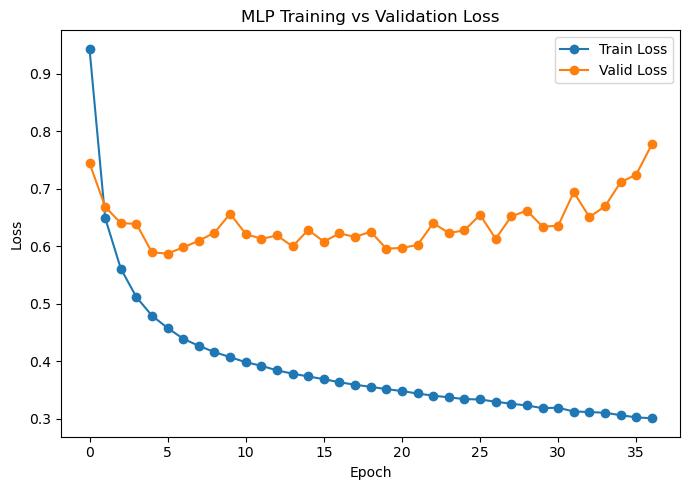

In [3]:
# ================== Cell 2: MLP Training (L2 + Time-aware Early Stopping)
#   + Train Loss + Validation Loss Curve ==================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, log_loss
from copy import deepcopy

# Assumed pre-computed variables:
# X_train_core_scaled, y_train_core, X_val_scaled, y_val,
# X_test_scaled, y_test_raw

# ----- Define the MLP Model -----
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),  # two hidden layers
    activation='relu',
    solver='adam',
    alpha=0.006,                  # L2 regularization
    max_iter=1,                   # one epoch per partial_fit
    warm_start=True,
    random_state=42
)

classes = np.unique(y_train_core)

max_epochs = 100
n_iter_no_change = 10            # patience for early stopping
best_val_acc = -np.inf
best_model = None
epochs_no_improve = 0

# ----- Lists for tracking loss and accuracy -----
train_losses = []
valid_losses = []
val_acc_list = []

# y_val is categorical (low/mid/high), convert to numeric for log_loss
class_to_idx = {c: i for i, c in enumerate(classes)}
y_val_numeric = np.array([class_to_idx[c] for c in y_val])

for epoch in range(max_epochs):

    # Shuffle training samples each epoch
    idx = np.arange(len(X_train_core_scaled))
    np.random.shuffle(idx)
    X_epoch = X_train_core_scaled[idx]
    y_epoch = y_train_core[idx]

    # First partial_fit requires the "classes" argument
    if epoch == 0:
        mlp.partial_fit(X_epoch, y_epoch, classes=classes)
    else:
        mlp.partial_fit(X_epoch, y_epoch)

    # ----- Training Loss -----
    train_losses.append(mlp.loss_)

    # ----- Validation Loss -----
    y_val_proba = mlp.predict_proba(X_val_scaled)
    valid_loss = log_loss(y_val_numeric, y_val_proba)
    valid_losses.append(valid_loss)

    # ----- Validation Accuracy -----
    y_val_pred = mlp.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch+1:03d} | "
          f"train_loss = {mlp.loss_:.4f} | "
          f"valid_loss = {valid_loss:.4f} | "
          f"val_acc = {val_acc:.4f}")

    # ----- Early Stopping -----
    if val_acc > best_val_acc + 1e-4:     # improvement threshold
        best_val_acc = val_acc
        best_model = deepcopy(mlp)
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= n_iter_no_change:
        print(f"\nEarly stopping at epoch {epoch+1}, "
              f"best val_acc = {best_val_acc:.4f}")
        break

# Restore the best model before stopping
if best_model is not None:
    mlp = best_model

# ================== Test Evaluation ==================
y_pred_mlp = mlp.predict(X_test_scaled)

print("\n" + "="*60)
print("Neural Network (MLP) Results with Full Loss Curves")
print("="*60)
print("Accuracy:", accuracy_score(y_test_raw, y_pred_mlp))
print("\nClassification report:\n", classification_report(y_test_raw, y_pred_mlp))

# ================== Plot: Train vs Validation Loss ==================
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss", marker='o')
plt.plot(valid_losses, label="Valid Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()


In [4]:
# ================== Cell 3: Logistic Regression + LightGBM + Naive Baseline ==================

# -------- Logistic Regression (Baseline) --------
log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features to similar ranges
    ('clf', LogisticRegression(
        multi_class='multinomial',
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)
y_pred_log = log_reg_pipeline.predict(X_test)

print("\n" + "="*60)
print("Logistic Regression (Baseline) Results")
print("="*60)
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification report:\n", classification_report(y_test, y_pred_log))

# -------- LightGBM --------
lgbm_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Optional: keep the same preprocessing as other models
    ('clf', LGBMClassifier(
        objective='multiclass',
        num_class=3,            # three target classes: low / mid / high
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42,
        n_jobs=-1,
        num_leaves=63,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        min_split_gain=0.01,
        reg_lambda=1.0
    ))
])

lgbm_pipeline.fit(X_train, y_train)
y_pred_lgbm = lgbm_pipeline.predict(X_test)

print("\n" + "="*60)
print("LightGBM Results")
print("="*60)
print("Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("\nClassification report:\n", classification_report(y_test, y_pred_lgbm))

# -------- Naive Baseline: CO(t) class as prediction for CO(t+H) --------
print("\n" + "="*60)
print("Naive Baseline (Use CO(t) class to predict CO(t+H))")
print("="*60)

# First, create class labels for current CO(GT) values (to match the target definition)
if USE_QUANTILE_BINS:
    train_df['CO_current_class'] = make_labels_by_quantiles(train_df['CO(GT)'])
    test_df['CO_current_class']  = make_labels_by_quantiles(test_df['CO(GT)'])
else:
    train_df['CO_current_class'] = make_labels_by_thresholds(train_df['CO(GT)'])
    test_df['CO_current_class']  = make_labels_by_thresholds(test_df['CO(GT)'])

# Naive prediction: use the current CO class as the prediction for future CO
y_pred_naive = test_df['CO_current_class'].values

# Evaluate the naive baseline
print("Accuracy:", accuracy_score(y_test, y_pred_naive))
print("\nClassification report:\n", classification_report(y_test, y_pred_naive))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_naive))


d:\Anaconda\envs\AI\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression (Baseline) Results
Accuracy: 0.7666963490650045

Classification report:
               precision    recall  f1-score   support

        high       0.86      0.74      0.80       718
         low       0.83      0.83      0.83       780
         mid       0.64      0.73      0.68       748

    accuracy                           0.77      2246
   macro avg       0.78      0.77      0.77      2246
weighted avg       0.78      0.77      0.77      2246

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004771 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 28258
[LightGBM] [Info] Number of data points in the train set: 7109, number of used features: 129
[LightGBM] [Info] Start training from score -1.147768
[LightGBM] [Info] Start training from score -1.062014
[LightGBM] [Info] Start training from score -1.087978
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\Anaconda\envs\AI\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


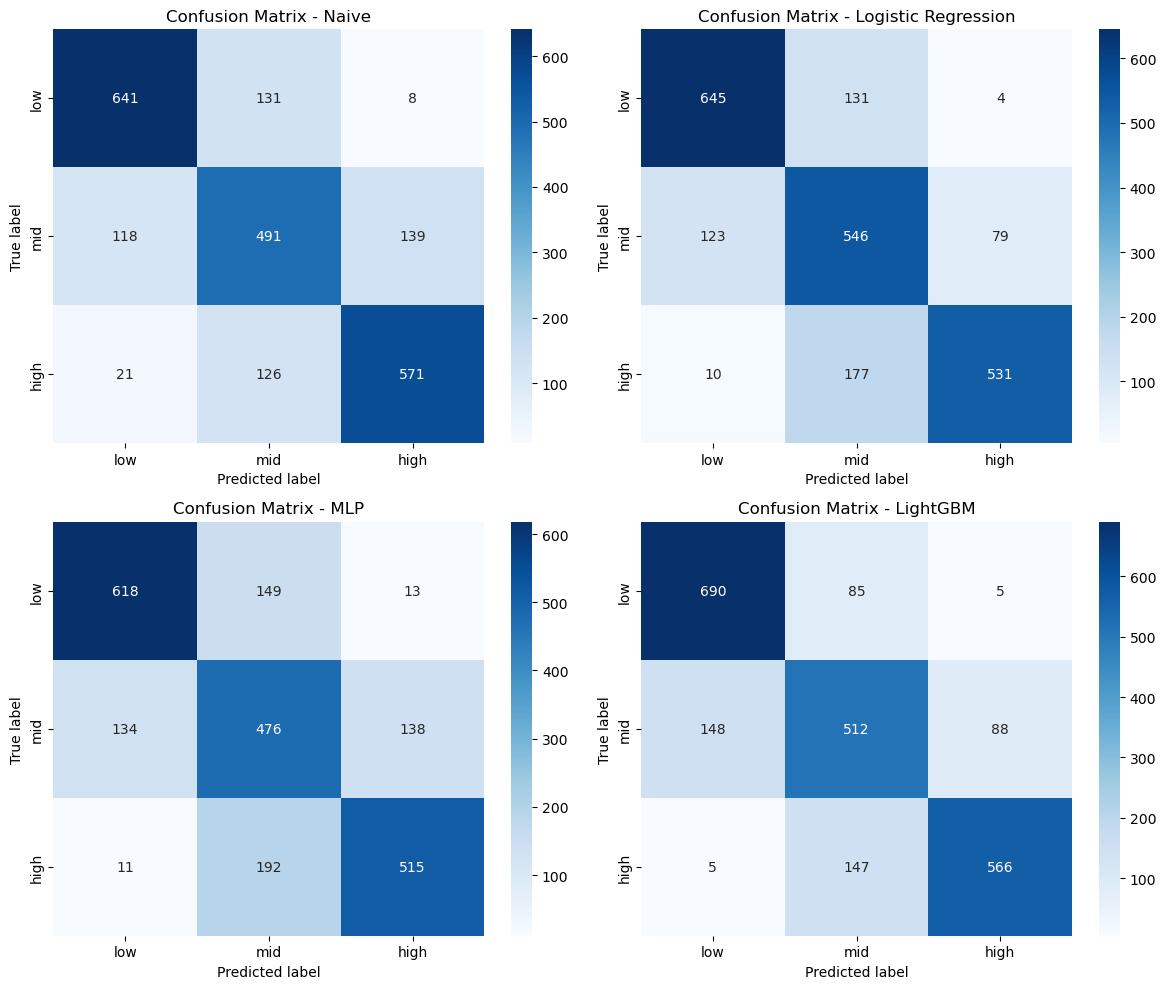


Model Comparison Summary
Naive                | Accuracy: 0.7582 | Macro-F1: 0.7578 | Macro-Precision: 0.7578 | Macro-Recall: 0.7578 | Balanced Acc: 0.7578
Logistic Regression  | Accuracy: 0.7667 | Macro-F1: 0.7690 | Macro-Precision: 0.7777 | Macro-Recall: 0.7655 | Balanced Acc: 0.7655
MLP                  | Accuracy: 0.7164 | Macro-F1: 0.7179 | Macro-Precision: 0.7220 | Macro-Recall: 0.7153 | Balanced Acc: 0.7153
LightGBM             | Accuracy: 0.7872 | Macro-F1: 0.7862 | Macro-Precision: 0.7885 | Macro-Recall: 0.7858 | Balanced Acc: 0.7858


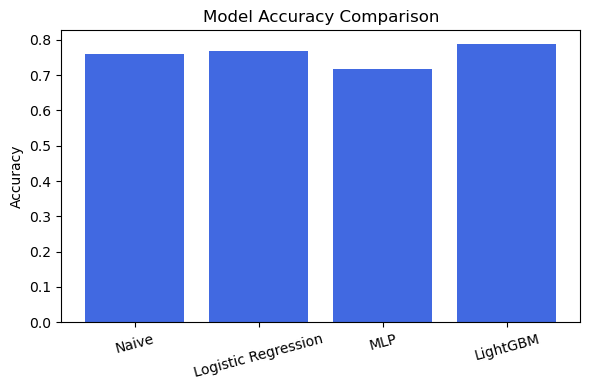

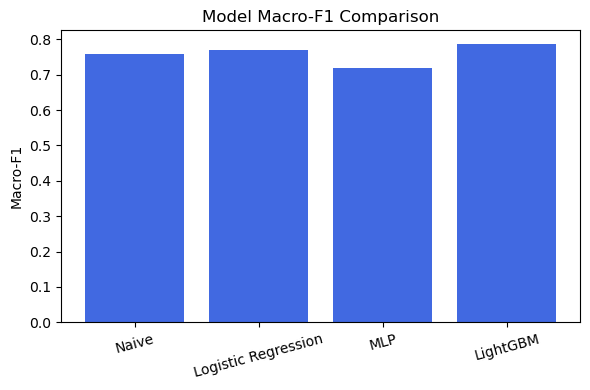

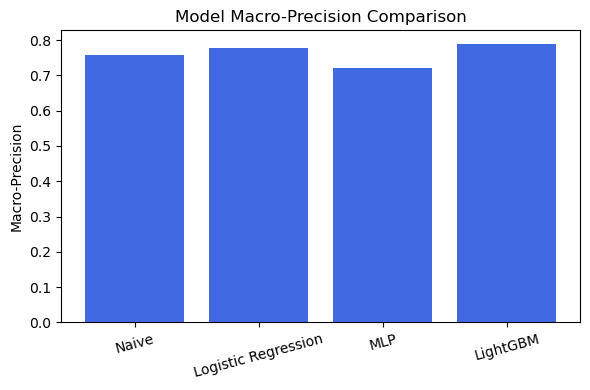

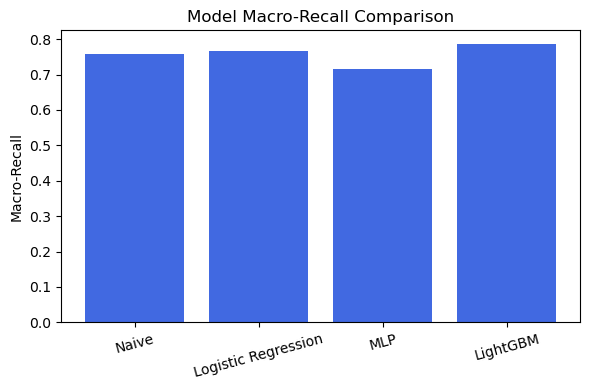

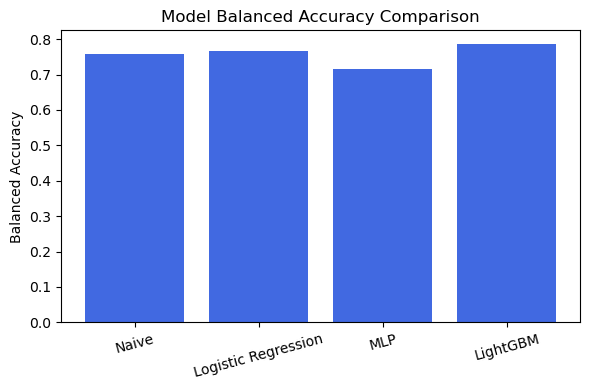

In [5]:
# ================== Cell 4: Final Evaluation & Plots ==================
import matplotlib.pyplot as plt
import seaborn as sns

pred_dict = {
    "Naive": y_pred_naive,
    "Logistic Regression": y_pred_log,
    "MLP": y_pred_mlp,
    "LightGBM": y_pred_lgbm,
}

# ---- 1) Confusion matrices (blue colormap) ----
plt.figure(figsize=(12, 10))

for i, (name, y_pred) in enumerate(pred_dict.items(), start=1):
    cm = confusion_matrix(y_test, y_pred, labels=labels_order)

    plt.subplot(2, 2, i)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=labels_order,
        yticklabels=labels_order,
        cmap="Blues"
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title(f"Confusion Matrix - {name}")

plt.tight_layout()
plt.show()

# ---- 2) Metrics summary (Accuracy, Macro-F1, Macro-Precision, Macro-Recall, Balanced Accuracy) ----
model_names = []
accuracies = []
macro_f1s = []
macro_precisions = []
macro_recalls = []
balanced_accuracies = []

for name, y_pred in pred_dict.items():
    model_names.append(name)
    accuracies.append(accuracy_score(y_test, y_pred))
    macro_f1s.append(f1_score(y_test, y_pred, labels=labels_order, average='macro'))
    macro_precisions.append(precision_score(y_test, y_pred, labels=labels_order, average='macro', zero_division=0))
    macro_recalls.append(recall_score(y_test, y_pred, labels=labels_order, average='macro', zero_division=0))
    balanced_accuracies.append(balanced_accuracy_score(y_test, y_pred))

print("\n" + "="*60)
print("Model Comparison Summary")
print("="*60)
for name, acc, f1_m, prec_m, rec_m, bal_acc in zip(
    model_names, accuracies, macro_f1s, macro_precisions, macro_recalls, balanced_accuracies
):
    print(f"{name:20s} | "
          f"Accuracy: {acc:.4f} | "
          f"Macro-F1: {f1_m:.4f} | "
          f"Macro-Precision: {prec_m:.4f} | "
          f"Macro-Recall: {rec_m:.4f} | "
          f"Balanced Acc: {bal_acc:.4f}")

# ---- 3) Bar charts ----

# (a) Accuracy
plt.figure(figsize=(6, 4))
plt.bar(model_names, accuracies, color="royalblue")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# (b) Macro-F1
plt.figure(figsize=(6, 4))
plt.bar(model_names, macro_f1s, color="royalblue")
plt.ylabel("Macro-F1")
plt.title("Model Macro-F1 Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# (c) Macro-Precision
plt.figure(figsize=(6, 4))
plt.bar(model_names, macro_precisions, color="royalblue")
plt.ylabel("Macro-Precision")
plt.title("Model Macro-Precision Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# (d) Macro-Recall
plt.figure(figsize=(6, 4))
plt.bar(model_names, macro_recalls, color="royalblue")
plt.ylabel("Macro-Recall")
plt.title("Model Macro-Recall Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# (e) Balanced Accuracy
plt.figure(figsize=(6, 4))
plt.bar(model_names, balanced_accuracies, color="royalblue")
plt.ylabel("Balanced Accuracy")
plt.title("Model Balanced Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()



LightGBM Feature Importance (Top 20)

                     feature  importance
0                     CO(GT)        1265
120         PT08.S1CO_x_COGT        1113
114             COGT_x_NO2GT         828
77     CO(GT)_rolling_std_6h         818
104         T_rolling_std_6h         816
13                      hour         799
95    NO2(GT)_rolling_std_6h         792
33        PT08.S1(CO)_lag_1h         790
113             COGT_x_NOxGT         782
1                PT08.S1(CO)         756
37       PT08.S1(CO)_lag_24h         751
126          fourier_cos_24h         733
98   NO2(GT)_rolling_std_12h         724
18             CO(GT)_lag_1h         722
53              CO(GT)_ma_3h         646
36       PT08.S1(CO)_lag_12h         639
2                   NMHC(GT)         630
27           NOx(GT)_lag_24h         626
51                RH_lag_12h         625
19             CO(GT)_lag_3h         624


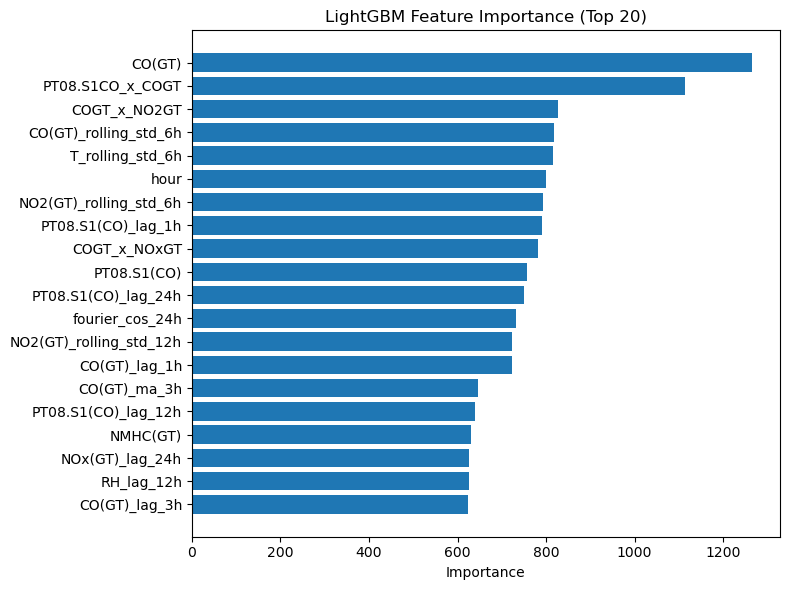

In [7]:
# ================== Cell X: LightGBM Feature Importance ==================
"""
This cell extracts LightGBM feature importances and maps them to the
original feature names defined in Cell 1 (feature_cols).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Extract the trained LightGBM model inside the pipeline
lgb_clf = lgbm_pipeline.named_steps['clf']

# 2) Get importance values (aligned with feature order in X_train)
importances = lgb_clf.feature_importances_

# 3) Feature names used during model training
#    These come from Cell 1 and match the order of columns in X_train
feature_names = feature_cols

# 4) Build a DataFrame for sorting and inspection
fi_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

print("\n===============================")
print("LightGBM Feature Importance (Top 20)")
print("===============================\n")
print(fi_df.head(20))

# 5) Optional: plot the top 20 features as a horizontal bar chart
top_k = 20
fi_top = fi_df.head(top_k)

plt.figure(figsize=(8, 6))
plt.barh(fi_top["feature"], fi_top["importance"])
plt.gca().invert_yaxis()   # Most important feature at the top
plt.xlabel("Importance")
plt.title("LightGBM Feature Importance (Top 20)")
plt.tight_layout()
plt.show()
